In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Prvih 5 redova sirovih cena:
                  WTI       BRENT     NVDA
Date                                      
2013-01-01  93.190002  111.400002  0.31925
2013-01-08  94.139999  111.879997  0.30500
2013-01-15  95.559998  110.610001  0.30425
2013-01-22  96.440002  113.480003  0.31525
2013-01-29  96.169998  115.599998  0.30400

Dimenzije: (522, 3)

Prvih 5 redova log-cena:
             log_WTI  log_BRENT  log_NVDA
Date                                     
2013-01-01  4.534640   4.713127 -1.141781
2013-01-08  4.544783   4.717427 -1.187443
2013-01-15  4.559754   4.706011 -1.189906

Prvih 5 redova log-razlika (prinosa):
            Δlog_WTI  Δlog_BRENT  Δlog_NVDA
Date                                       
2013-01-08  0.010143    0.004300  -0.045663
2013-01-15  0.014971   -0.011416  -0.002462
2013-01-22  0.009167    0.025616   0.035516


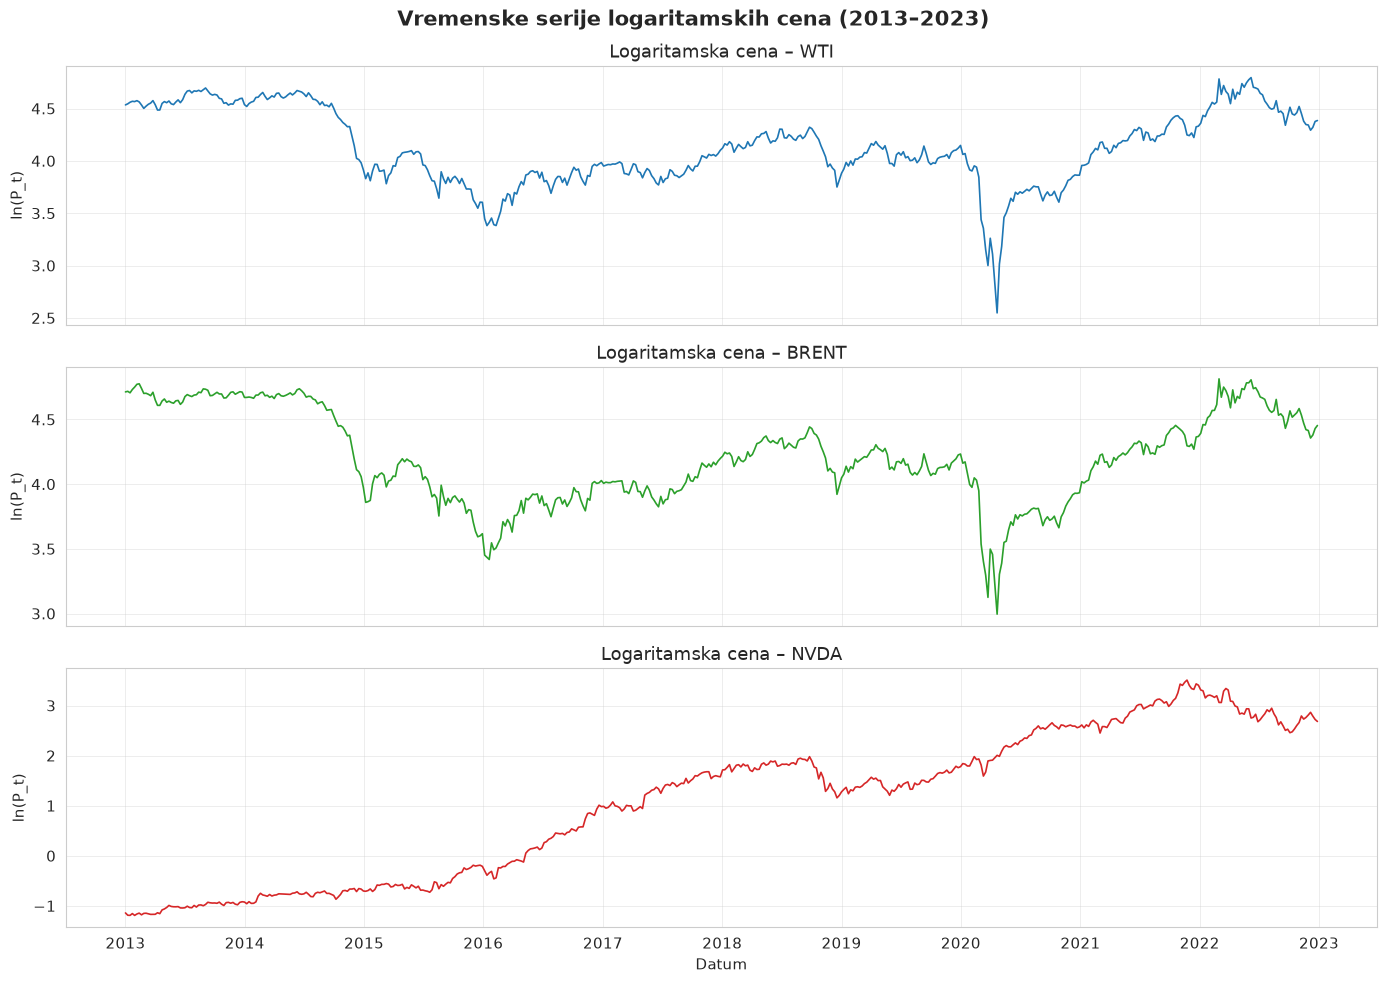

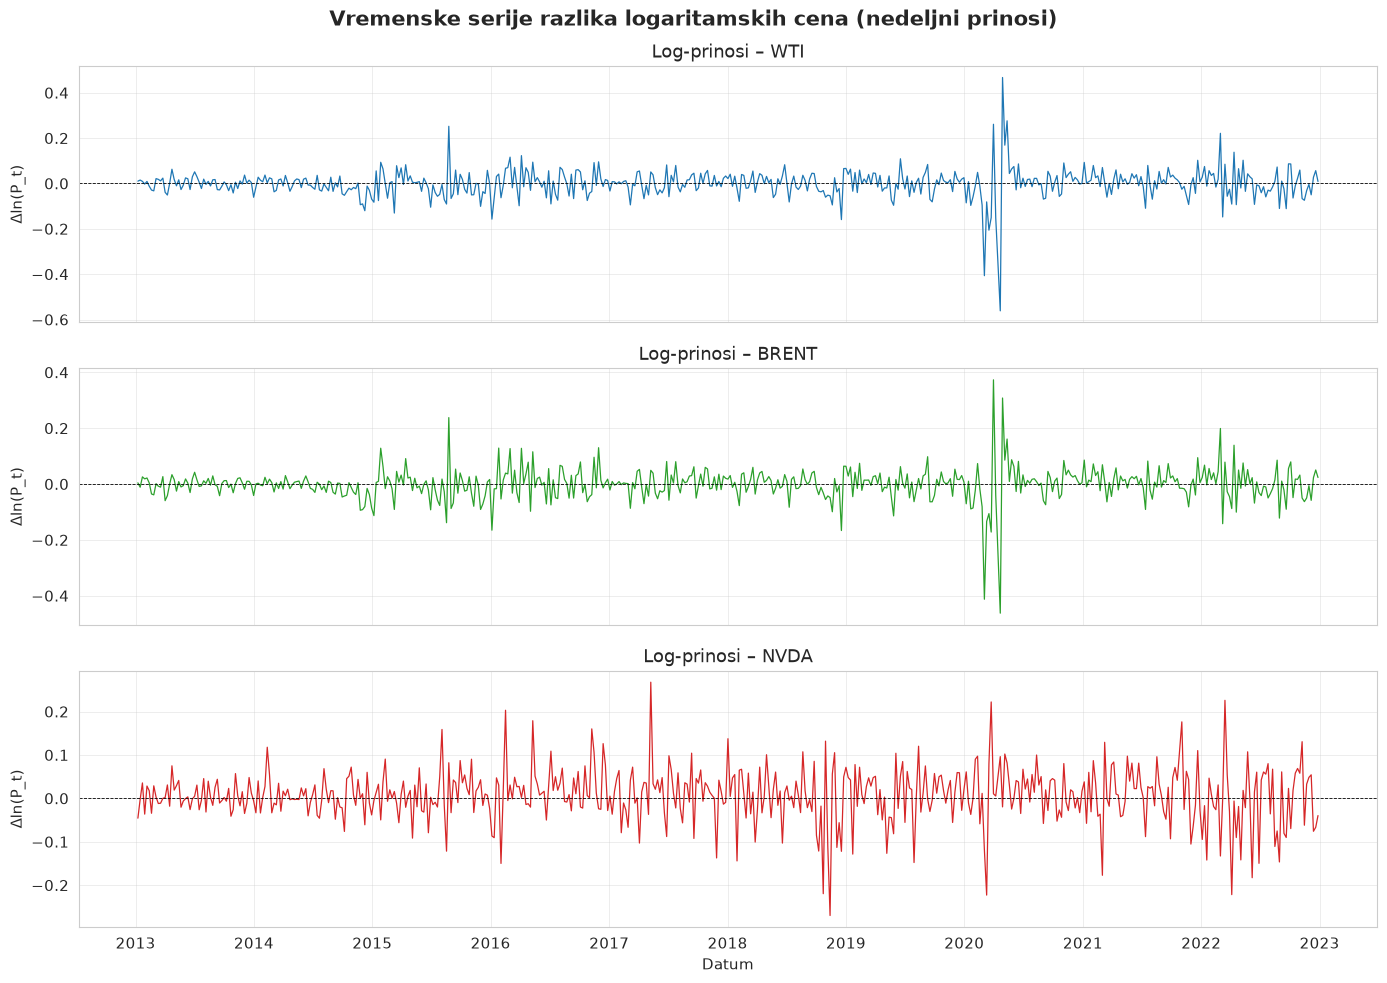

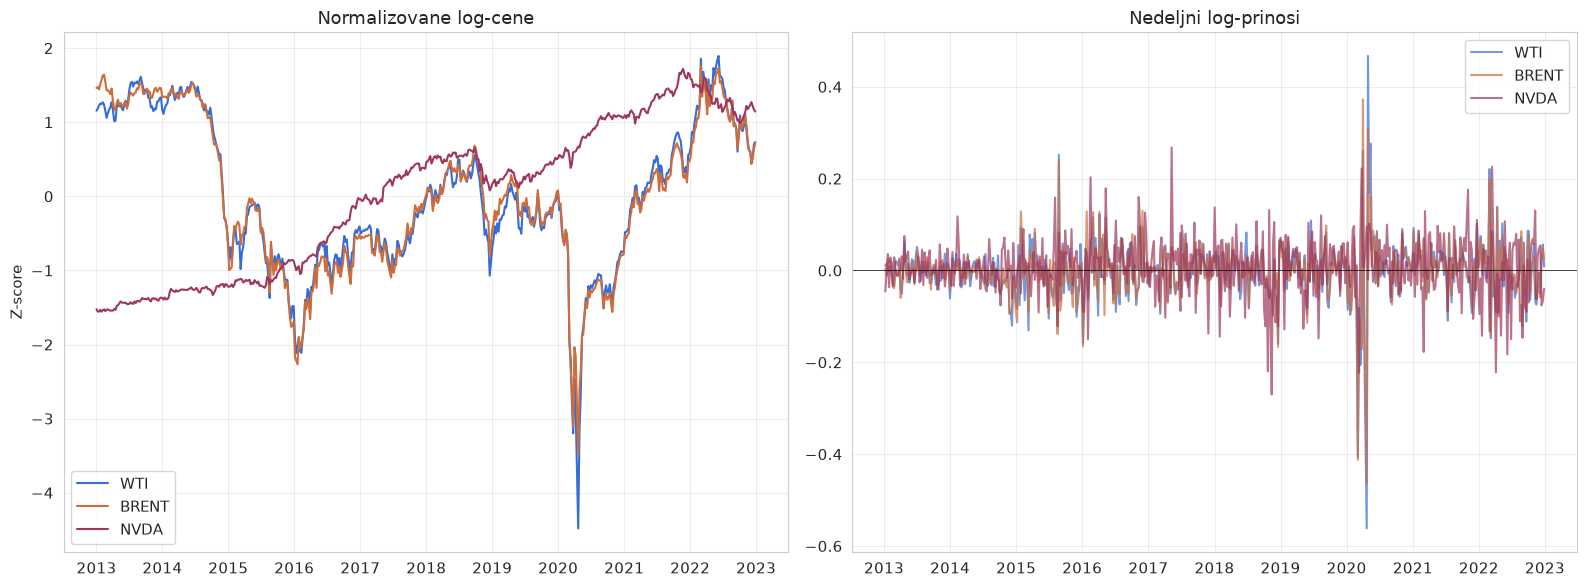

In [7]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

start_date = "2013-01-01"
end_date   = "2023-01-01"

tikeri = {
    "WTI":   "CL=F",
    "BRENT": "BZ=F",
    "NVDA":  "NVDA"
}

podaci = {}
for naziv, tiker in tikeri.items():
    df = yf.download(tiker, start=start_date, end=end_date, interval="1wk",
                     progress=False, auto_adjust=False)
    podaci[naziv] = df['Close'].copy()

cene = pd.concat(podaci, axis=1)
cene.columns = tikeri.keys()
cene = cene.dropna()

print("Prvih 5 redova sirovih cena:")
print(cene.head())
print("\nDimenzije:", cene.shape)
cene = cene[cene > 0].dropna()

log_cene = np.log(cene)
log_cene.columns = [f"log_{c}" for c in log_cene.columns]

log_razlike = log_cene.diff().dropna()
log_razlike.columns = [f"Δ{col}" for col in log_razlike.columns]

print("\nPrvih 5 redova log-cena:")
print(log_cene.head(3))
print("\nPrvih 5 redova log-razlika (prinosa):")
print(log_razlike.head(3))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

boje = {"log_WTI": "tab:blue", "log_BRENT": "tab:green", "log_NVDA": "tab:red"}

for ax, col in zip(axes, log_cene.columns):
    ax.plot(log_cene.index, log_cene[col], color=boje[col], linewidth=1.2)
    ax.set_title(f"Logaritamska cena – {col.replace('log_','')}", fontsize=13)
    ax.set_ylabel("ln(P_t)")

axes[-1].set_xlabel("Datum")
fig.suptitle("Vremenske serije logaritamskih cena (2013–2023)", fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig("log_cene.png", dpi=150)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, log_razlike.columns):
    ax.plot(log_razlike.index, log_razlike[col],
            color=boje[col.replace('Δ','')], linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f"Log-prinosi – {col.replace('Δlog_','').replace('log_','')}", fontsize=13)
    ax.set_ylabel("Δln(P_t)")

axes[-1].set_xlabel("Datum")
fig.suptitle("Vremenske serije razlika logaritamskih cena (nedeljni prinosi)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig("log_razlike.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

norm_log = (log_cene - log_cene.mean()) / log_cene.std()
for col in norm_log.columns:
    axes[0].plot(norm_log.index, norm_log[col], label=col.replace('log_',''))
axes[0].set_title("Normalizovane log-cene")
axes[0].set_ylabel("Z-score")
axes[0].legend()

for col in log_razlike.columns:
    axes[1].plot(log_razlike.index, log_razlike[col], alpha=0.7,
                 label=col.replace('Δlog_','').replace('log_',''))
axes[1].set_title("Nedeljni log-prinosi")
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()